In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visual_functions import expected_calibration_error, plot_model_metrics, analyze_line_movement_perf, plot_juice_histogram
from utils import calc_net_odds, print_gender_accuracy

from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

In [2]:
df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_train_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')
df_train_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')

df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


In [3]:
df_vegas = pd.concat([df_train_open, df_test_open], ignore_index=True)[['Date','winner', 'fighter_red', 'fighter_blue', 'weight_class', 
                                                                        'date', 'open_red', 'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
                                                                        'proba_fair_open_red', 'proba_fair_open_blue', 'proba_fair_close1_red', 'proba_fair_close1_blue', 'proba_fair_close2_red', 'proba_fair_close2_blue']]



In [4]:
def vegas_acc_over_time(df_, odds_type, acc_type='accuracy', by_year=True):
    df = df_.copy()
    df = df.sort_values('Date', ascending=True)
    df['vegas_pred'] = np.where(df[f'{odds_type}_red'] <= df[f'{odds_type}_blue'], 1, 0)

    accs = []
    if by_year:
        df['year'] = pd.to_datetime(df['Date']).dt.year
        year_groups = df.groupby('year')
        for year, group in year_groups:

            if acc_type == 'accuracy':
                acc = accuracy_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'f1':
                acc = f1_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'brier':
                acc = brier_score_loss(group['winner'], group[f'proba_fair_{odds_type}_red'])
            
            accs.append((year, acc))
    
    else:
        event_groups = df.groupby('Date')
        for date, group in event_groups:
            acc = accuracy_score(group['winner'], group['vegas_pred'])
            accs.append((date, acc))
    return accs


def plot_vegas_acc(ax_row, df_, odds_type, acc_type='accuracy',
                   title1='', title2='', by_year=True):

    accs = vegas_acc_over_time(df_, odds_type, acc_type, by_year)

    years = [x[0] for x in accs]
    vals = [x[1] for x in accs]

    # Left plot
    ax_row[0].plot(years, vals, marker='o')
    ax_row[0].set_title(f'{title1}, mean:{np.mean(vals):.2f}')
    ax_row[0].set_xlabel('Year' if by_year else 'Date')
    ax_row[0].set_ylabel(acc_type.capitalize())

    # Year-to-year difference
    diffs = [vals[i] - vals[i-1] for i in range(1, len(vals))]

    # Right plot
    ax_row[1].plot(years[1:], diffs, marker='o')
    ax_row[1].set_title(title2)
    ax_row[1].set_xlabel('Year' if by_year else 'Date')
    ax_row[1].set_ylabel(acc_type.capitalize())



In [5]:
fig, ax = plt.subplots(3, 2, figsize=(14, 12))

metrics = [
    ('accuracy', 'Vegas Fighter Accuracy over Time', 'Change in Accuracy Year to Year'),
    ('brier', 'Vegas Brier Score', 'Change in Brier Score'),
    ('f1', 'Vegas F1 Score', 'Change in F1 Score')
]

for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'open',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Opening Odds')
plt.tight_layout()
plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_vegas_metrics.png", dpi=300, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(3, 2, figsize=(14,12))
for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'close1',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Close1 Odds')
plt.tight_layout()

plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_vegas_metrics.png", dpi=300, bbox_inches="tight")
plt.close(fig)


fig, ax = plt.subplots(3, 2, figsize=(14,12))
for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'close2',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Close2 Odds')
plt.tight_layout()

plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_vegas_metrics.png", dpi=300, bbox_inches="tight")
plt.close(fig)


In [6]:
def plot_vegas_metrics(df_, odds_type):
    df = df_.copy()
    
    df['vegas_pred'] = np.where(df[f'{odds_type}_red'] < df[f'{odds_type}_blue'], 1, 0)
    df['vegas_pred_fair_proba'] = np.where(df[f'{odds_type}_red'] < df[f'{odds_type}_blue'], df[f'proba_fair_{odds_type}_red'], df[f'proba_fair_{odds_type}_blue'])
    
    plot_model_metrics(df['winner'].values, df['vegas_pred'].values, df[f'proba_fair_{odds_type}_red'].values)
    
    print(f"Vegas Accuracy ({odds_type}):", accuracy_score(df['winner'].values, df['vegas_pred'].values))
    print(f"Vegas F1 Score ({odds_type}):", f1_score(df['winner'].values, df['vegas_pred'].values))
    print(f"Vegas Brier Score Loss ({odds_type}):", brier_score_loss(df['winner'].values, df[f'proba_fair_{odds_type}_red'].values))

    

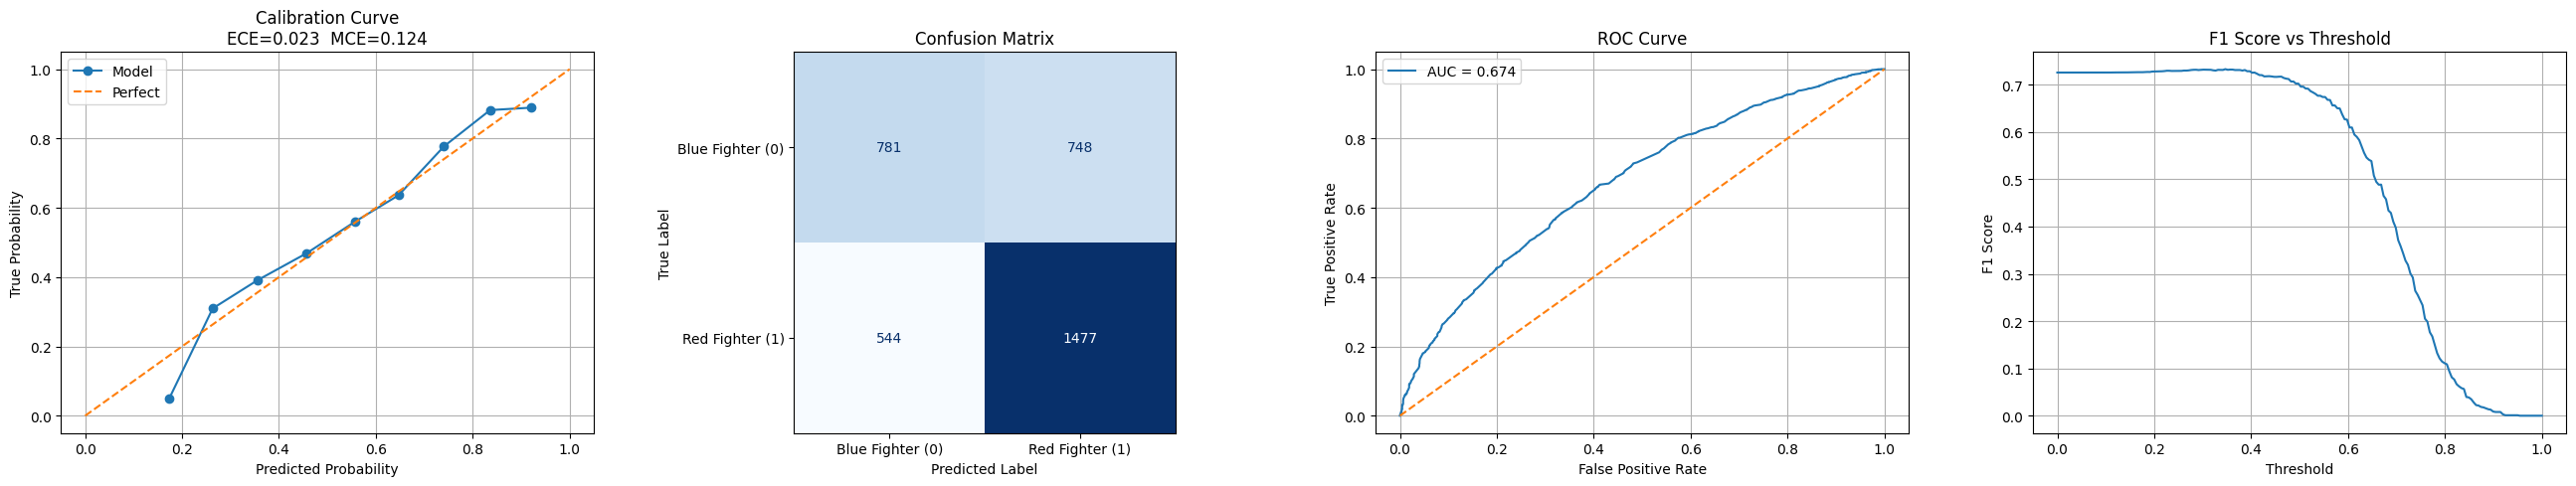

Vegas Accuracy (open): 0.636056338028169
Vegas F1 Score (open): 0.6957136128120585
Vegas Brier Score Loss (open): 0.2230479739784933


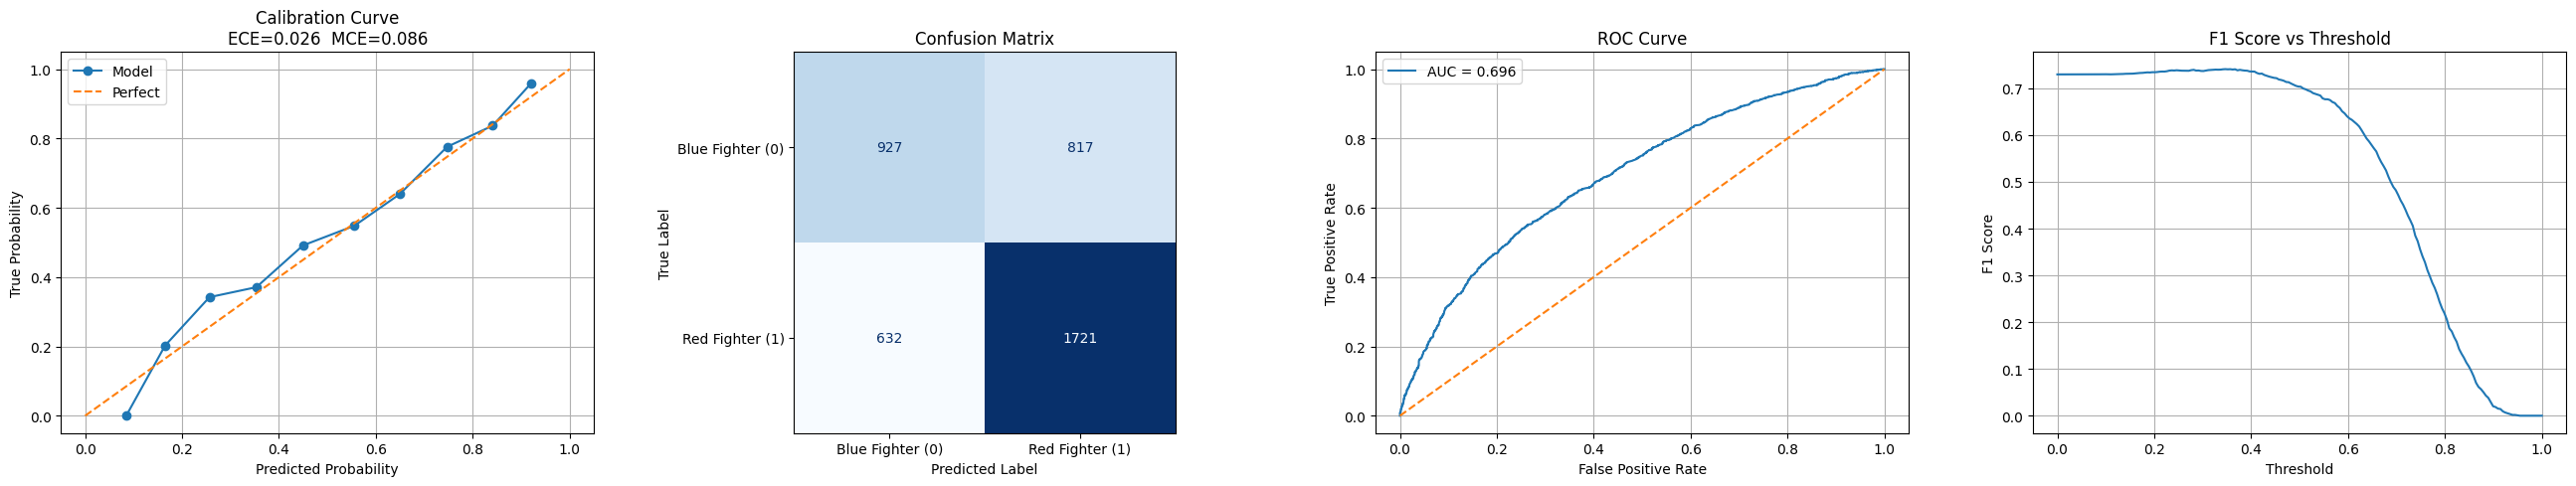

Vegas Accuracy (close1): 0.646326580424701
Vegas F1 Score (close1): 0.7037415661418933
Vegas Brier Score Loss (close1): 0.21729118665157302


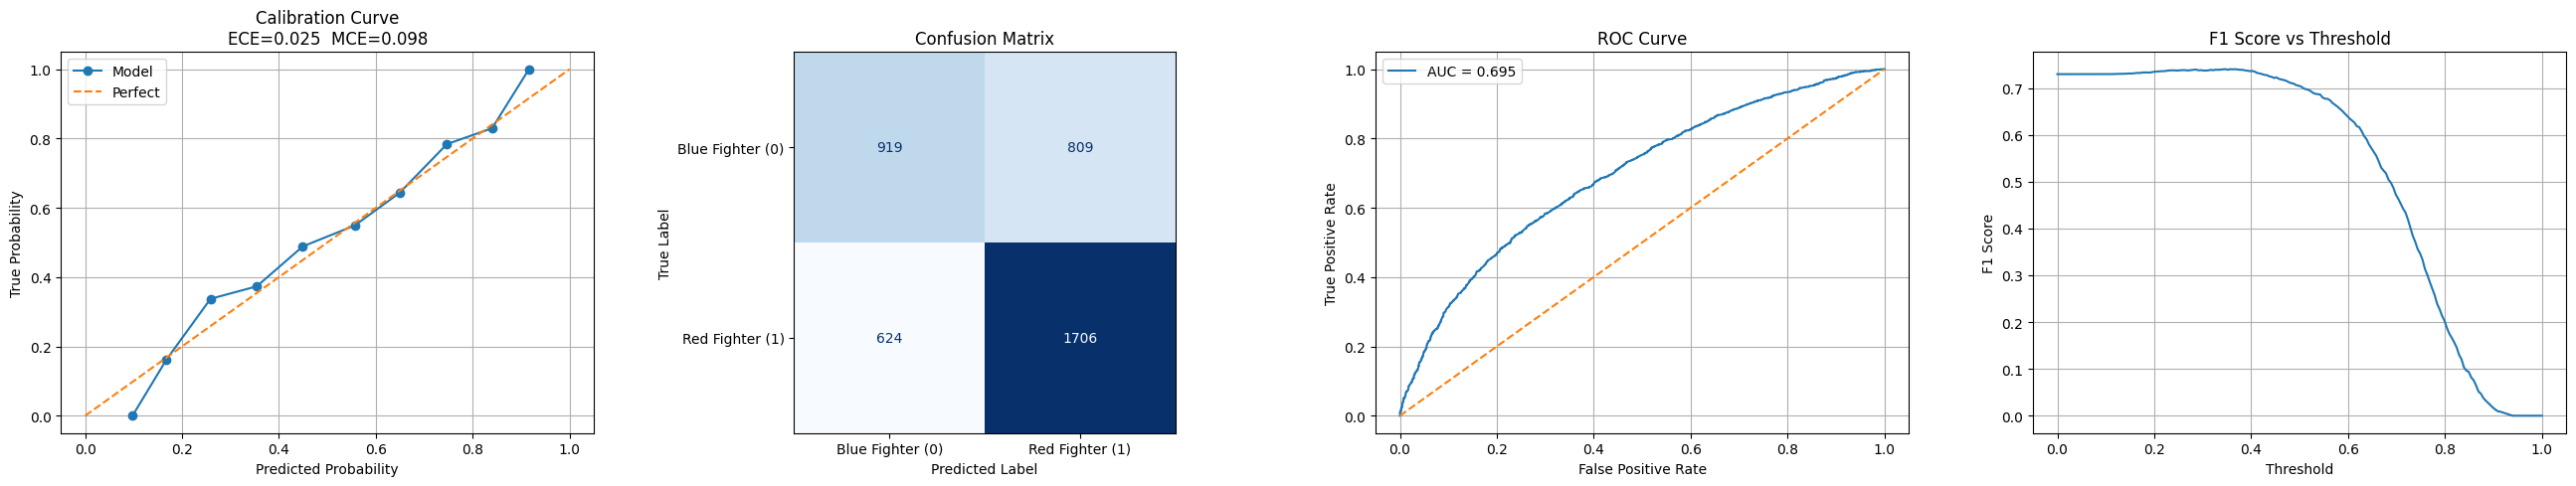

Vegas Accuracy (close2): 0.6468703794972893
Vegas F1 Score (close2): 0.7042311661506708
Vegas Brier Score Loss (close2): 0.21742433493949864


In [7]:
plot_vegas_metrics(df_train_open, 'open')
plot_vegas_metrics(df_train_close1, 'close1')   
plot_vegas_metrics(df_train_close2, 'close2')

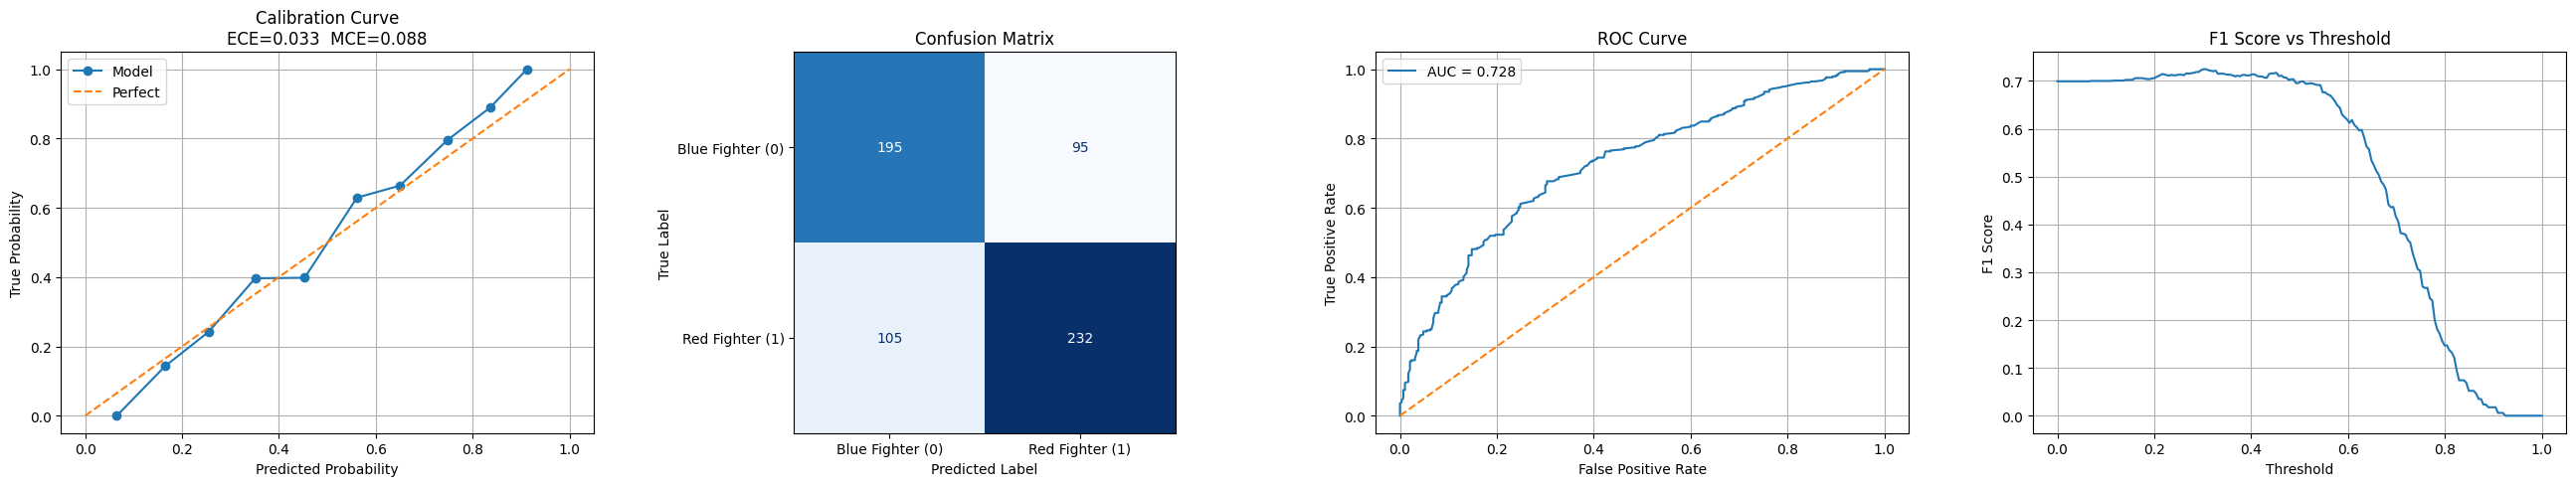

Vegas Accuracy (open): 0.6810207336523126
Vegas F1 Score (open): 0.6987951807228916
Vegas Brier Score Loss (open): 0.20968077165462776


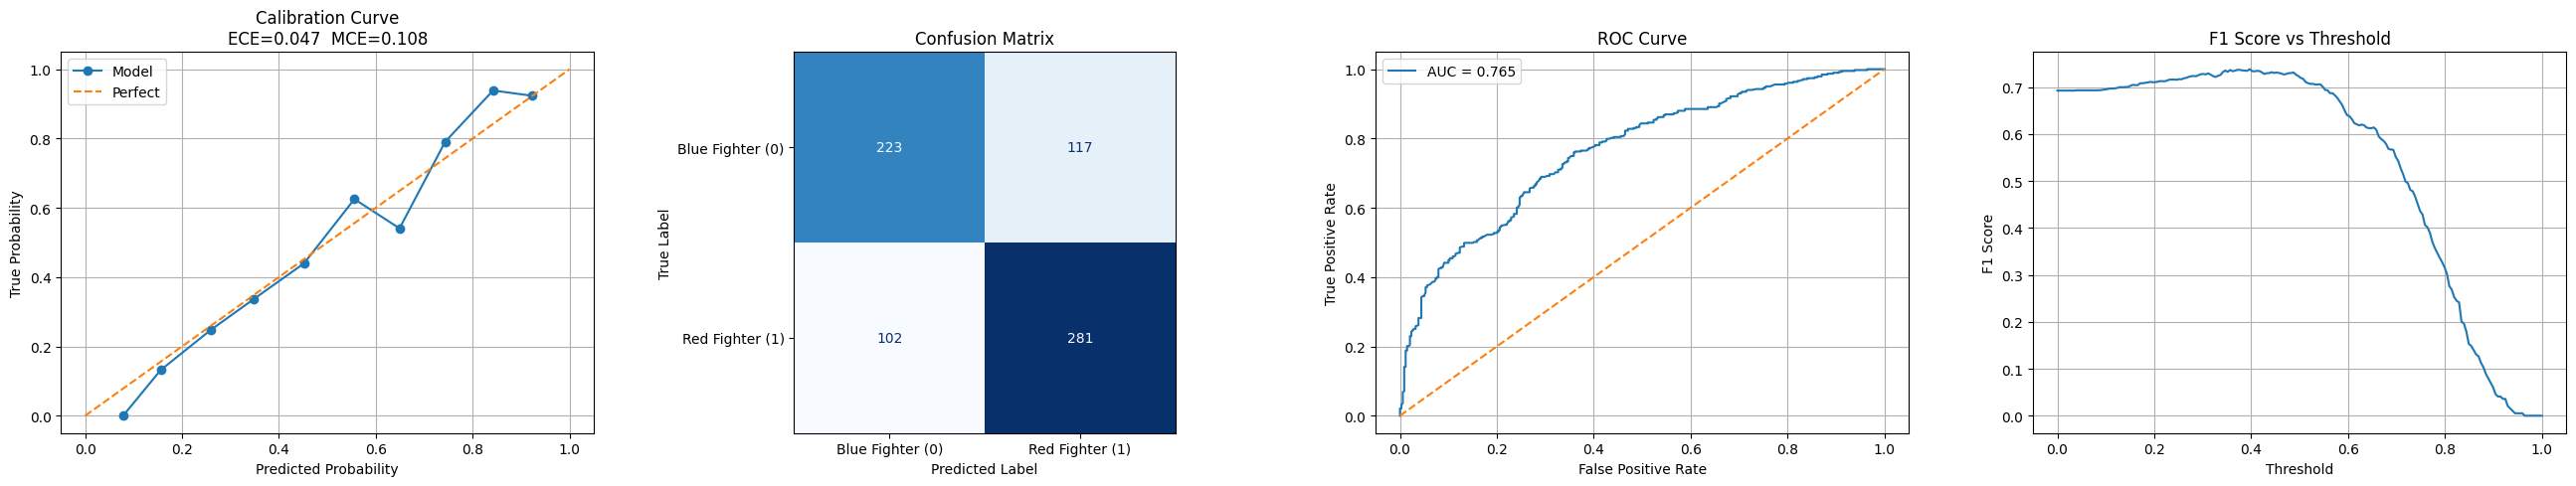

Vegas Accuracy (close1): 0.6970954356846473
Vegas F1 Score (close1): 0.7195902688860435
Vegas Brier Score Loss (close1): 0.19717200657219433


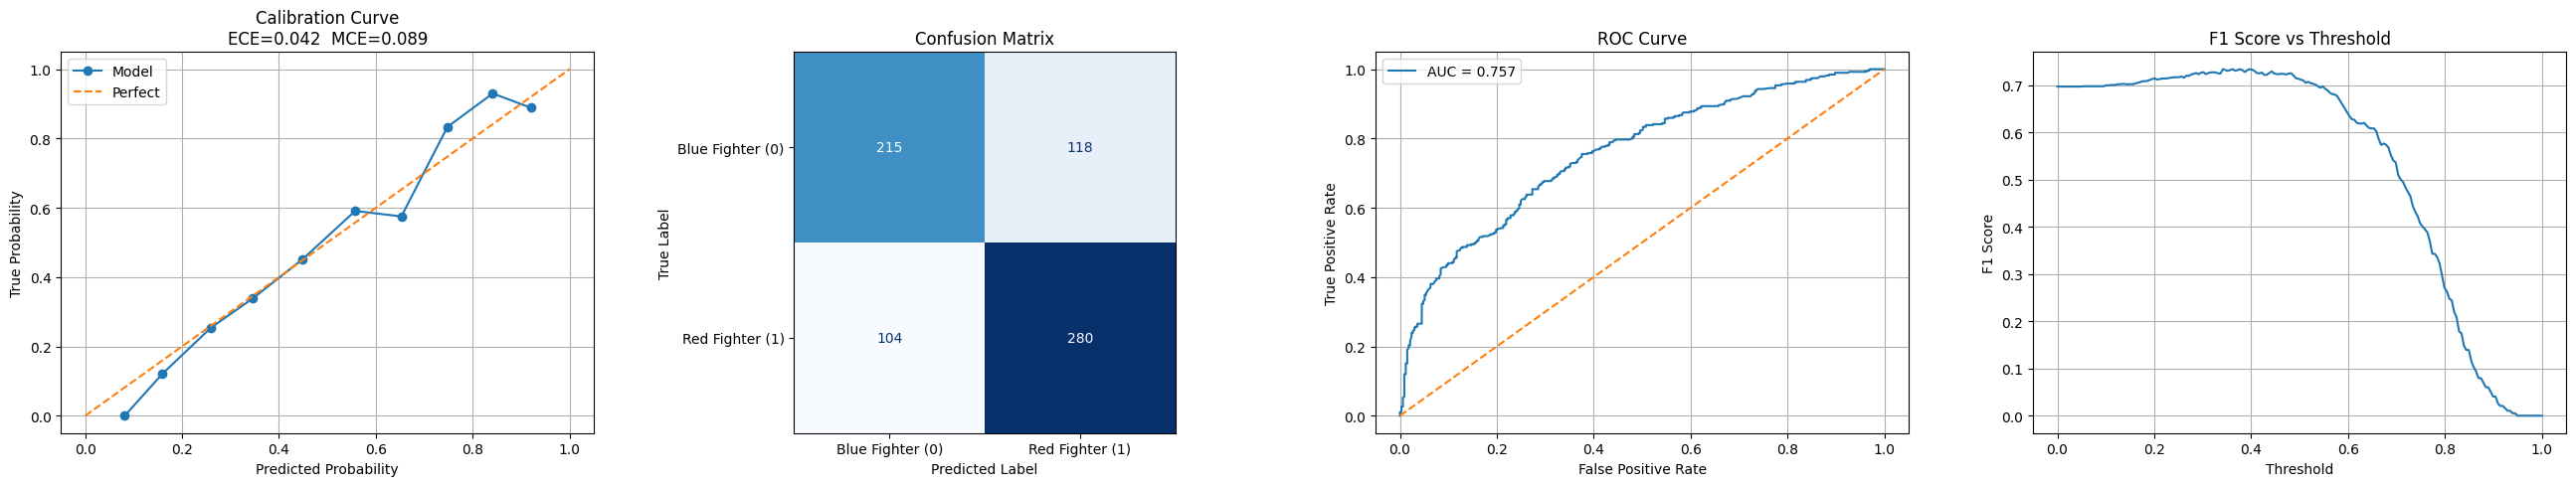

Vegas Accuracy (close2): 0.6903765690376569
Vegas F1 Score (close2): 0.7161125319693095
Vegas Brier Score Loss (close2): 0.20039974334376337


In [8]:
plot_vegas_metrics(df_test_open, 'open')
plot_vegas_metrics(df_test_close1, 'close1')   
plot_vegas_metrics(df_test_close2, 'close2')

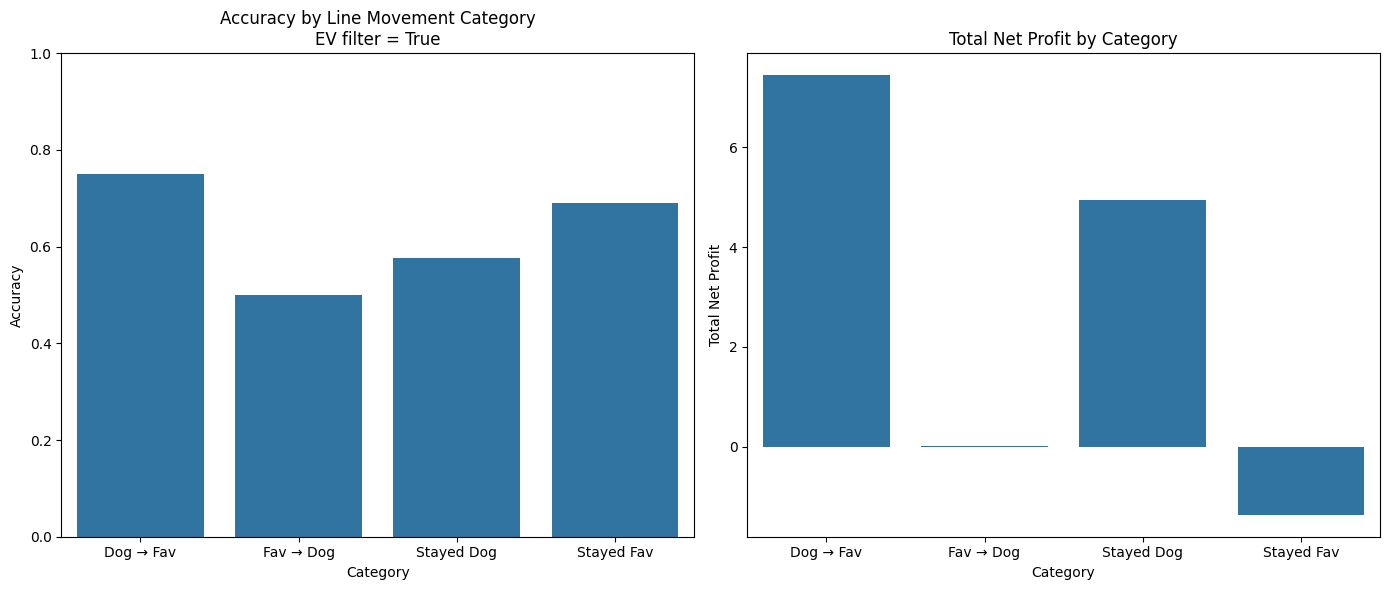

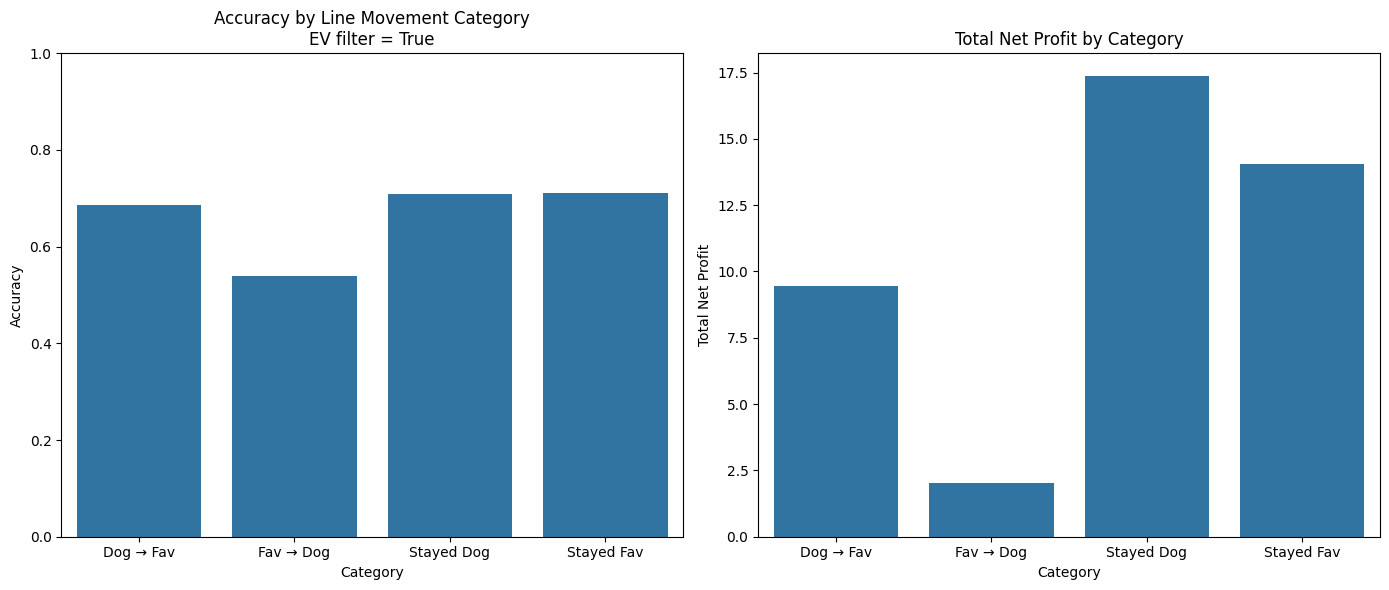

,movement_category,accuracy,n,total_profit,mean_EV
0,Dog → Fav,0.685185,54,9.467102,0.093323
1,Fav → Dog,0.538462,13,2.010000,0.425654
2,Stayed Dog,0.709677,31,17.363951,0.172836
3,Stayed Fav,0.710692,318,14.047038,0.070075


In [9]:

analyze_line_movement_perf(df_test_close1, 'close1')
analyze_line_movement_perf(df_test_close2, 'close2')

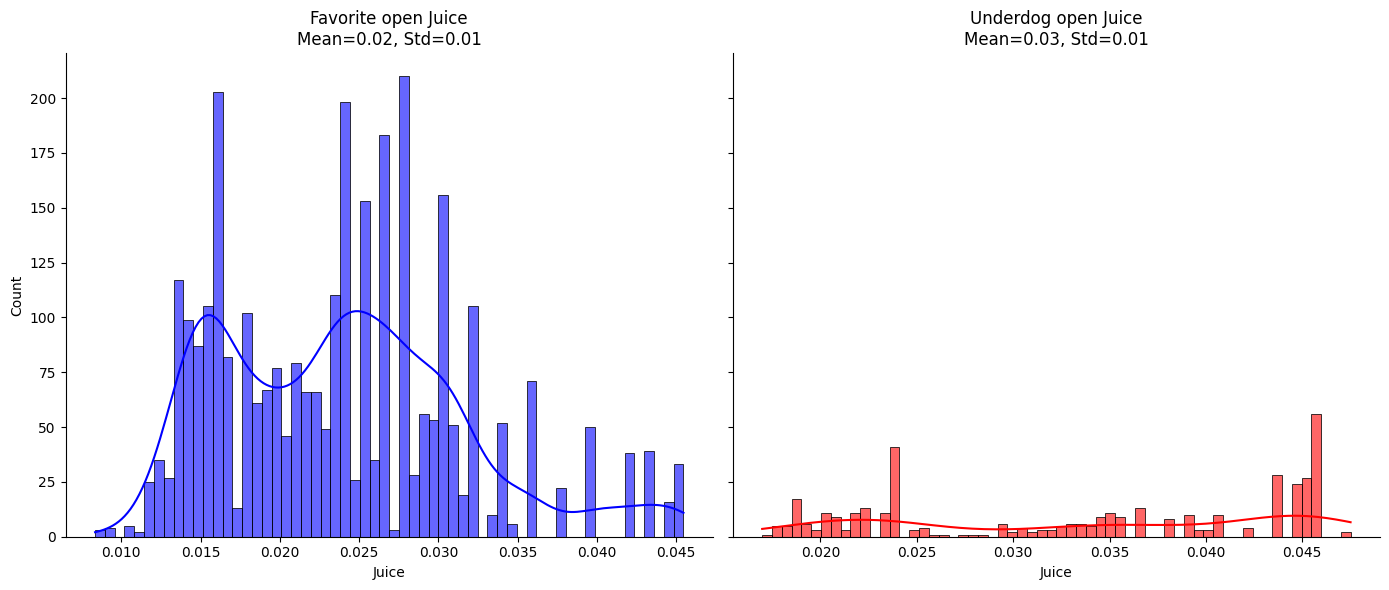

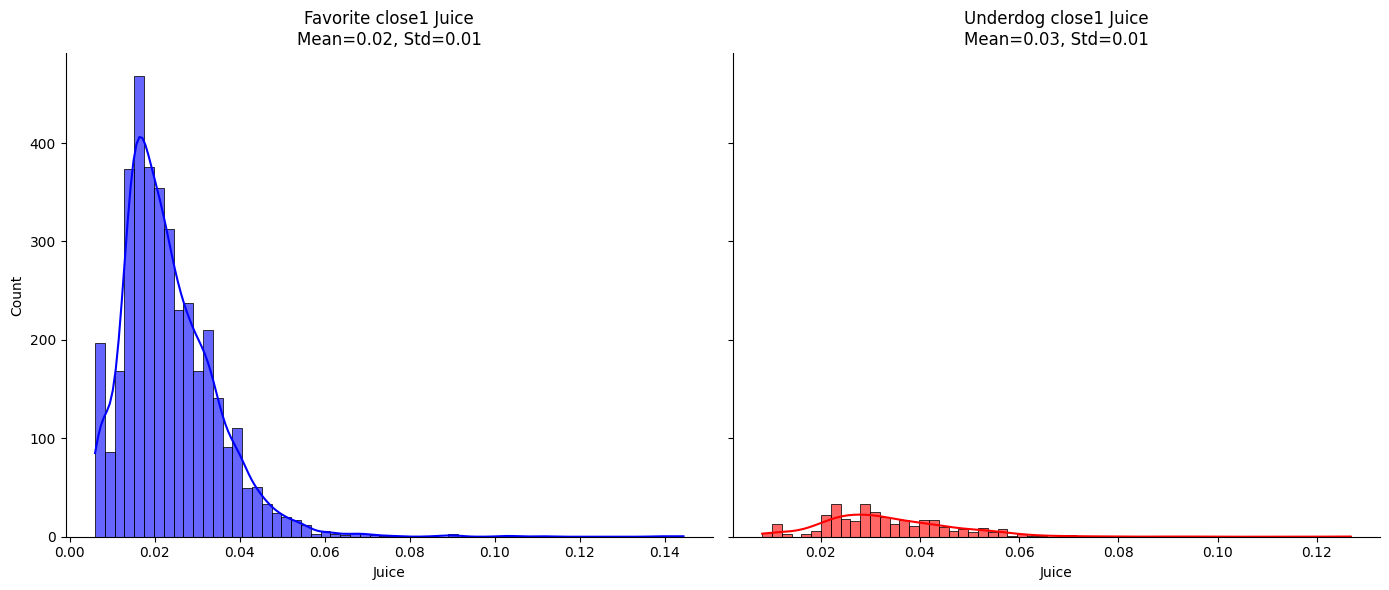

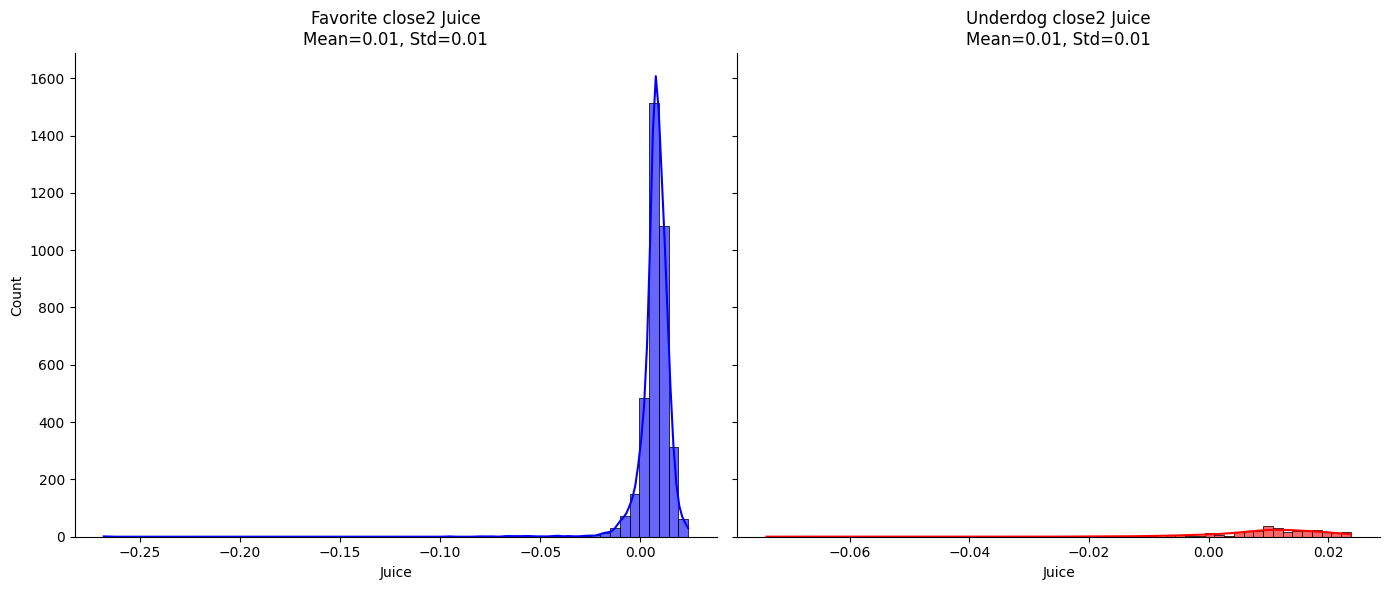

In [10]:
plot_juice_histogram(df_train_open, 'open')
plot_juice_histogram(df_train_close1, 'close1')
plot_juice_histogram(df_train_close2, 'close2')

In [14]:
check = 1
if check: 
    print('check is not none')

if not check: 
    print('check is none')

check is not none


In [11]:
calc_net_odds(df_test_open, 'open')
calc_net_odds(df_test_close1, 'close1')
calc_net_odds(df_test_close2, 'close2')

(345, 306) (627, 306)
Sum of decimal odds for favorite predictions (adjusted): 28.375110393171582
Sum of decimal odds for underdog predictions (adjusted): 35.47193874661164
Fav bets: 271 total, 203 correct, 68 incorrect, 74.91% correct
Dog bets: 74 total, 50 correct, 24 incorrect, 67.57% correct
(261, 299) (723, 299)
Sum of decimal odds for favorite predictions (adjusted): 6.084063993116619
Sum of decimal odds for underdog predictions (adjusted): 4.962059946862594
Fav bets: 227 total, 159 correct, 68 incorrect, 70.04% correct
Dog bets: 34 total, 19 correct, 15 incorrect, 55.88% correct
(416, 299) (717, 299)
Sum of decimal odds for favorite predictions (adjusted): 23.51413985789636
Sum of decimal odds for underdog predictions (adjusted): 19.37395070948469
Fav bets: 372 total, 263 correct, 109 incorrect, 70.70% correct
Dog bets: 44 total, 29 correct, 15 incorrect, 65.91% correct


In [12]:
print_gender_accuracy(df_test_open)
print_gender_accuracy(df_test_close1)     
print_gender_accuracy(df_test_close2)

Accuracy for Men weight classes:   0.714
Accuracy for Women weight classes: 0.708
Accuracy for Men weight classes:   0.705
Accuracy for Women weight classes: 0.726
Accuracy for Men weight classes:   0.708
Accuracy for Women weight classes: 0.704
